In [1]:
using LinearAlgebra
using Plots
using QuadGK
using Roots
using FastGaussQuadrature

In [2]:
Nf = 4.0
m = 0.0037
w = 0.4
D = 1.0
Lambda2 = 1e6
epsilon2 = 1e-4
Lambda_PV = 2e2
Lambda_QCD = 0.234
gamma_m = 12/(33 - 2 * Nf)
mu = 19.0

19.0

In [3]:
F_UV(k2) = 4 * pi^2 * gamma_m * (1 - exp(-k2)) / ( 0.5 * log(exp(2) - 1 + (1 + k2 / Lambda_QCD^2)^2) )
G(k2) = D/w^6 * 4 * pi^2 * k2^2 * exp(-k2 / w^2) + F_UV(k2);
pk(p, q, z) = p^2 - p*q*z
qk(p, q, z) = p*q*z - q^2
k2(p, q, z) = p^2 + q^2 - 2*p*q*z;

In [4]:
x, w_t = gausslegendre(100)
z, w_z = gausschebyshevu(100) # Chebyshev second kind
t = 0.5 * (log(Lambda2) - log(epsilon2)) * x .+ 0.5 * (log(Lambda2) + log(epsilon2));

In [5]:
A = 0.3 .* rand(length(t)) .+ 1.3
B = 0.1 .* rand(length(t)) .+ 0.4
mu_i = argmin(abs.(t .- 2*log(mu)))
sqrt(exp(t[mu_i]))

function z_intB(t_i, p2)
    k2_here = k2.(sqrt(p2), exp(t_i/2), z)
    integrand = @. w_z * G(k2_here) / k2_here * (Lambda_PV^2 / (k2_here + Lambda_PV^2))
    return sum(integrand)
end


function z_intA(t_i, p2)
    k2_here = k2.(sqrt(p2), exp(t_i/2), z)
    integrand = @. w_z * ( sqrt(p2)*exp(t_i/2)*z + 2*pk(sqrt(p2), exp(t_i/2), z)*qk(sqrt(p2), exp(t_i/2), z)/k2_here ) * G(k2_here) / k2_here * (Lambda_PV^2 / (k2_here + Lambda_PV^2))
    return sum(integrand)
end

z_intA (generic function with 1 method)

In [6]:
function part_B(p2)
    Z_2 = 1 - A[mu_i]
    Z_4m = m - B[mu_i]
    integrand = @. w_t * exp(2*t) * B / (exp(t) * A^2 + B^2) * z_intB(t, p2)
    return Z_4m + Z_2^2 * 4/(2pi)^3 * sum( integrand )
end

function part_A(p2)
    Z_2 = 1 - A[mu_i]
    integrand = @. w_t * exp(2*t) * A / (exp(t) * A + B) * z_intA(t, p2)
    return Z_2 + Z_2^2 * 4/(3*(2pi)^3) * sum( integrand )
end

part_A (generic function with 1 method)

In [ ]:
function update(A,B)
    alpha = 0.2
    first = part_B.(exp.(t))
    second = part_A.(exp.(t))
    max_A = maximum(abs.(A .- second))
    max_B = maximum(abs.(B .- first))
    println(max_A, max_B)
    return alpha .* second .+ (1-alpha) .* A, alpha .* first .+ (1-alpha) .* B
end

update (generic function with 1 method)

2.7747282249634964e-105.163572887410123e-9


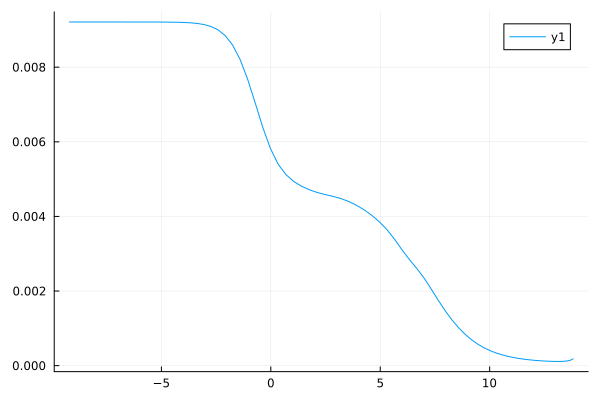

In [134]:
A,B = update(A,B)


plot(t, B./A)

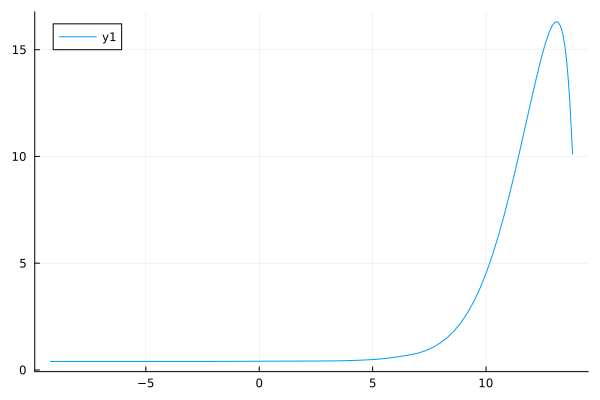

In [114]:
plot(t, A)

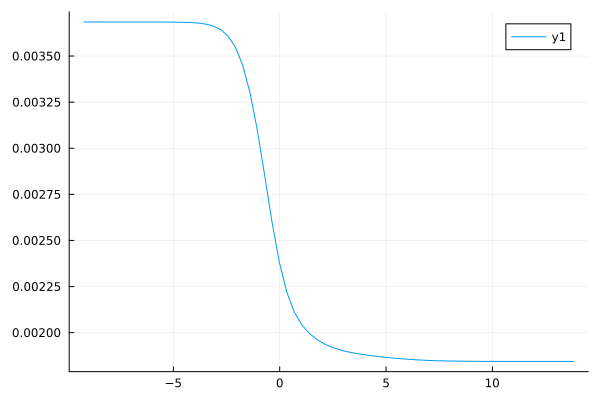

In [110]:
plot(t,B)